# Modelling

This notebook develops and evaluates models for the next-category recommendation task.

The processed dataset contains one row per historical prediction opportunity, with household, customer, property, AI-derived and video-derived information available at that moment.

Train, validation and test partitions are created by `Property_ID` to prevent historical states from the same household appearing across multiple datasets.

## Packages

CatBoost is needed for the tuned CatBoost models below. The next cell installs it **only if it is missing** (nothing happens when it is already installed). If it is installed here, restart the kernel once and run the notebook again from the top.

In [2]:
import importlib
import importlib.util

for package in ["catboost"]:
    if importlib.util.find_spec(package) is None:
        print(f"{package} is missing: installing it into this kernel ...")
        %pip install -q {package}
        importlib.invalidate_caches()
    else:
        print(f"{package} is installed")


catboost is missing: installing it into this kernel ...
Note: you may need to restart the kernel to use updated packages.


In [3]:
# -------------------------------------------------------------------
# Imports And Data Loading
# -------------------------------------------------------------------

from pathlib import Path

import pandas as pd

DATA_PATH = Path("../../data/processed/classification/model_state_with_reg.csv")

model_state = pd.read_csv(
    DATA_PATH,
    parse_dates=["Prediction_Time"],
)

print("MODELLING DATASET LOADED")
print("-" * 60)

print(f"Rows:       {len(model_state):,}")
print(f"Properties: {model_state['Property_ID'].nunique():,}")
print(f"Columns:    {model_state.shape[1]:,}")

MODELLING DATASET LOADED
------------------------------------------------------------
Rows:       431
Properties: 234
Columns:    65


## Grouped Train Validation Test Split

The modelling dataset is partitioned by property rather than by individual rows.

This ensures that historical prediction states from the same household remain within a single partition, preventing information from the same property from leaking across training, validation and final test sets.

In [4]:
# -------------------------------------------------------------------
# Grouped Train / Validation / Test Split
# -------------------------------------------------------------------

from sklearn.model_selection import GroupShuffleSplit

# Separate predictors, target and grouping variable.
X = model_state.drop(
    columns=[
        "Next_Category_ID",
        "Next_Category",
    ]
).copy()

y = model_state["Next_Category"].copy()
groups = model_state["Property_ID"].copy()

# ---------------------------------------------------------------
# First split:
# 70% Train
# 30% Temporary
# ---------------------------------------------------------------

train_splitter = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42,
)

train_idx, temp_idx = next(
    train_splitter.split(
        X,
        y,
        groups=groups,
    )
)

X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()

X_temp = X.iloc[temp_idx].copy()
y_temp = y.iloc[temp_idx].copy()

temp_groups = groups.iloc[temp_idx].copy()

# ---------------------------------------------------------------
# Second split:
# Temporary -> 50% Validation / 50% Test
#
# Final proportions:
# Train      ~70%
# Validation ~15%
# Test       ~15%
# ---------------------------------------------------------------

validation_splitter = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=42,
)

val_idx, test_idx = next(
    validation_splitter.split(
        X_temp,
        y_temp,
        groups=temp_groups,
    )
)

X_val = X_temp.iloc[val_idx].copy()
y_val = y_temp.iloc[val_idx].copy()

X_test = X_temp.iloc[test_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

# ---------------------------------------------------------------
# Leakage check
# ---------------------------------------------------------------

train_properties = set(X_train["Property_ID"])
val_properties = set(X_val["Property_ID"])
test_properties = set(X_test["Property_ID"])

print("GROUPED DATA SPLIT")
print("-" * 60)

print(
    f"Train:      {len(X_train):>3} rows | "
    f"{X_train['Property_ID'].nunique():>3} properties"
)

print(
    f"Validation: {len(X_val):>3} rows | "
    f"{X_val['Property_ID'].nunique():>3} properties"
)

print(
    f"Test:       {len(X_test):>3} rows | "
    f"{X_test['Property_ID'].nunique():>3} properties"
)

print()

print(
    "Train / Validation overlap:",
    len(train_properties & val_properties),
)

print(
    "Train / Test overlap:      ",
    len(train_properties & test_properties),
)

print(
    "Validation / Test overlap: ",
    len(val_properties & test_properties),
)


GROUPED DATA SPLIT
------------------------------------------------------------
Train:      309 rows | 163 properties
Validation:  67 rows |  35 properties
Test:        55 rows |  36 properties

Train / Validation overlap: 0
Train / Test overlap:       0
Validation / Test overlap:  0


## Majority Class Baseline

A simple majority-class classifier is used as the initial benchmark.

This baseline always predicts the most frequent next category observed in the training data. More advanced models must provide measurable improvement over this reference while the final test set remains untouched.

In [5]:
# -------------------------------------------------------------------
# Majority Class Baseline
# -------------------------------------------------------------------

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

# The baseline does not learn from the predictors.
# It simply predicts the most frequent class observed in training.
baseline_model = DummyClassifier(
    strategy="most_frequent",
)

baseline_model.fit(
    X_train,
    y_train,
)

# Evaluate only on the validation set.
baseline_predictions = baseline_model.predict(X_val)

baseline_accuracy = accuracy_score(
    y_val,
    baseline_predictions,
)

baseline_macro_f1 = f1_score(
    y_val,
    baseline_predictions,
    average="macro",
    zero_division=0,
)

baseline_weighted_f1 = f1_score(
    y_val,
    baseline_predictions,
    average="weighted",
    zero_division=0,
)

print("MAJORITY CLASS BASELINE")
print("-" * 60)

print(
    f"Most frequent training class: "
    f"{baseline_model.classes_[baseline_model.class_prior_.argmax()]}"
)

print()
print(f"Validation Accuracy:    {baseline_accuracy:.4f}")
print(f"Validation Macro F1:    {baseline_macro_f1:.4f}")
print(f"Validation Weighted F1: {baseline_weighted_f1:.4f}")

MAJORITY CLASS BASELINE
------------------------------------------------------------
Most frequent training class: Other Items

Validation Accuracy:    0.2239
Validation Macro F1:    0.0610
Validation Weighted F1: 0.0819


## Logistic Regression Baseline

A multinomial Logistic Regression model is used as the first learned benchmark.

Categorical encoding, missing-value imputation and numerical scaling are fitted exclusively on the training partition through a scikit-learn pipeline. Property and customer identifiers, together with the prediction timestamp, are excluded from the predictors to avoid memorisation of household identities or arbitrary temporal identifiers.

In [6]:
# -------------------------------------------------------------------
# Logistic Regression Baseline
# -------------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    top_k_accuracy_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ---------------------------------------------------------------
# Remove identifiers and timestamp from the model predictors.
# Property_ID is still retained separately for grouped splitting,
# but it should not be learned as a predictive feature.
# ---------------------------------------------------------------

excluded_features = [
    "Property_ID",
    "Customer_ID",
    "Prediction_Time",
]

X_train_model = X_train.drop(
    columns=excluded_features,
    errors="ignore",
).copy()

X_val_model = X_val.drop(
    columns=excluded_features,
    errors="ignore",
).copy()

# ---------------------------------------------------------------
# Identify numerical and categorical predictors.
# ---------------------------------------------------------------

categorical_features = (
    X_train_model
    .select_dtypes(include=["object", "bool"])
    .columns
    .tolist()
)

numerical_features = (
    X_train_model
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

# ---------------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

# ---------------------------------------------------------------
# Model
# ---------------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(
    X_train_model,
    y_train,
)

# ---------------------------------------------------------------
# Validation predictions
# ---------------------------------------------------------------

logistic_predictions = logistic_model.predict(
    X_val_model
)

logistic_probabilities = logistic_model.predict_proba(
    X_val_model
)

classes = logistic_model.named_steps[
    "classifier"
].classes_

# ---------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------

logistic_accuracy = accuracy_score(
    y_val,
    logistic_predictions,
)

logistic_macro_f1 = f1_score(
    y_val,
    logistic_predictions,
    average="macro",
    zero_division=0,
)

logistic_weighted_f1 = f1_score(
    y_val,
    logistic_predictions,
    average="weighted",
    zero_division=0,
)

logistic_top2 = top_k_accuracy_score(
    y_val,
    logistic_probabilities,
    k=2,
    labels=classes,
)

logistic_top3 = top_k_accuracy_score(
    y_val,
    logistic_probabilities,
    k=3,
    labels=classes,
)

print("LOGISTIC REGRESSION BASELINE")
print("-" * 60)

print(f"Validation Accuracy:    {logistic_accuracy:.4f}")
print(f"Validation Macro F1:    {logistic_macro_f1:.4f}")
print(f"Validation Weighted F1: {logistic_weighted_f1:.4f}")
print(f"Validation Top-2 Acc:   {logistic_top2:.4f}")
print(f"Validation Top-3 Acc:   {logistic_top3:.4f}")

LOGISTIC REGRESSION BASELINE
------------------------------------------------------------
Validation Accuracy:    0.3582
Validation Macro F1:    0.3360
Validation Weighted F1: 0.3480
Validation Top-2 Acc:   0.5672
Validation Top-3 Acc:   0.7910


## Regression Features Included In Every Model

This copy of the notebook reads `model_state_with_reg.csv` (built by `03_ky_regression_feature_merging` and stored in `data/processed/classification/`), which is `model_state.csv` plus five columns derived from the household-value regression:

| column | meaning |
|---|---|
| `documented_value_nv` | documented value of the non-vehicle items at the prediction time |
| `reg_pred_total_nv` | regression estimate of the household's total non-vehicle contents value (-1 when there is no estimate) |
| `reg_pred_gap_nv` | estimated value not yet documented (-1 when there is no estimate) |
| `reg_completeness_nv` | documented value / estimated total (-1 when there is no estimate) |
| `reg_available` | 1 if at least 10 non-vehicle items with a value were documented, else 0 |

Every model below (Logistic Regression, Random Forest, CatBoost, the regularised versions, the AI ablation, the feature importance and the final holdout evaluation) is fitted on `X_train_model`, `X_val_model` or `X_test_model`, which keep every column except the identifiers and the prediction timestamp. The five columns are therefore predictors of all models. The next cell checks this and counts the states that have a regression estimate; the AI ablation removes only the columns that start with `ai_`.

In [7]:
# -------------------------------------------------------------------
# Regression Features Included In Every Model
# -------------------------------------------------------------------

REGRESSION_FEATURES = [
    "documented_value_nv",
    "reg_pred_total_nv",
    "reg_pred_gap_nv",
    "reg_completeness_nv",
    "reg_available",
]

# The five columns must be predictors of every model: present in the
# model inputs and treated as numerical features by the preprocessing.
for name, frame in {
    "train": X_train_model,
    "validation": X_val_model,
    "test": X_test.drop(columns=excluded_features, errors="ignore"),
}.items():
    missing = [column for column in REGRESSION_FEATURES if column not in frame.columns]
    assert not missing, f"{name}: missing {missing}"

assert set(REGRESSION_FEATURES) <= set(numerical_features)
assert not any(column.startswith("ai_") for column in REGRESSION_FEATURES)

print("REGRESSION FEATURES IN THE MODEL INPUTS")
print("-" * 60)
print(f"Predictors per model:           {X_train_model.shape[1]}")
print(f"  of which regression features: {len(REGRESSION_FEATURES)}")
print(f"  of which AI features:         {sum(c.startswith('ai_') for c in X_train_model.columns)}")

print()
print("States with a regression estimate (reg_available = 1):")
for name, frame in {"train": X_train, "validation": X_val, "test": X_test}.items():
    print(
        f"  {name:<11} {int(frame['reg_available'].sum()):>3} of {len(frame):>3} states "
        f"({frame['reg_available'].mean():.1%})"
    )

print()
print("States without an estimate carry -1 in the three estimate columns.")


REGRESSION FEATURES IN THE MODEL INPUTS
------------------------------------------------------------
Predictors per model:           60
  of which regression features: 5
  of which AI features:         13

States with a regression estimate (reg_available = 1):
  train        53 of 309 states (17.2%)
  validation   10 of  67 states (14.9%)
  test          8 of  55 states (14.5%)

States without an estimate carry -1 in the three estimate columns.


## Random Forest Model

A Random Forest classifier is evaluated as a non-linear alternative to Logistic Regression.

The model can capture interactions between household composition, AI-derived signals and customer or property context. Class weighting is applied to reduce the dominance of the more frequent target categories.

In [8]:
# -------------------------------------------------------------------
# Random Forest Model
# -------------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

# Reuse the same preprocessing structure to ensure a fair comparison.
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# Train only on the training partition.
random_forest_model.fit(
    X_train_model,
    y_train,
)

# Validation predictions.
rf_predictions = random_forest_model.predict(
    X_val_model
)

rf_probabilities = random_forest_model.predict_proba(
    X_val_model
)

rf_classes = random_forest_model.named_steps[
    "classifier"
].classes_

# Evaluation metrics.
rf_accuracy = accuracy_score(
    y_val,
    rf_predictions,
)

rf_macro_f1 = f1_score(
    y_val,
    rf_predictions,
    average="macro",
    zero_division=0,
)

rf_weighted_f1 = f1_score(
    y_val,
    rf_predictions,
    average="weighted",
    zero_division=0,
)

rf_top2 = top_k_accuracy_score(
    y_val,
    rf_probabilities,
    k=2,
    labels=rf_classes,
)

rf_top3 = top_k_accuracy_score(
    y_val,
    rf_probabilities,
    k=3,
    labels=rf_classes,
)

print("RANDOM FOREST")
print("-" * 60)

print(f"Validation Accuracy:    {rf_accuracy:.4f}")
print(f"Validation Macro F1:    {rf_macro_f1:.4f}")
print(f"Validation Weighted F1: {rf_weighted_f1:.4f}")
print(f"Validation Top-2 Acc:   {rf_top2:.4f}")
print(f"Validation Top-3 Acc:   {rf_top3:.4f}")

RANDOM FOREST
------------------------------------------------------------
Validation Accuracy:    0.4776
Validation Macro F1:    0.4132
Validation Weighted F1: 0.4208
Validation Top-2 Acc:   0.6119
Validation Top-3 Acc:   0.7612


## Tuned CatBoost Model

CatBoost is evaluated as a stronger non-linear model for the next-category recommendation task.

Hyperparameters are tuned using grouped cross-validation so that historical states from the same property remain within the same fold. Macro F1 is used as the primary optimisation metric to account for the imbalanced multiclass target.

In [9]:
# -------------------------------------------------------------------
# Tuned CatBoost Model
# -------------------------------------------------------------------

from catboost import CatBoostClassifier
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

# ---------------------------------------------------------------
# CatBoost works well with encoded tabular data, so we reuse the
# existing preprocessing pipeline for a fair comparison.
# ---------------------------------------------------------------

catboost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            CatBoostClassifier(
                loss_function="MultiClass",
                verbose=0,
                random_seed=42,
                auto_class_weights="Balanced",
                thread_count=-1,
            ),
        ),
    ]
)

# ---------------------------------------------------------------
# Search space
# ---------------------------------------------------------------

catboost_param_grid = {
    "classifier__iterations": [
        300,
        500,
        800,
        1200,
    ],
    "classifier__depth": [
        4,
        5,
        6,
        7,
        8,
    ],
    "classifier__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
    ],
    "classifier__l2_leaf_reg": [
        1,
        3,
        5,
        7,
        10,
    ],
    "classifier__random_strength": [
        0.0,
        0.5,
        1.0,
        2.0,
    ],
    "classifier__bagging_temperature": [
        0.0,
        0.5,
        1.0,
        2.0,
        5.0,
    ],
}

# ---------------------------------------------------------------
# Grouped cross-validation
# ---------------------------------------------------------------

group_cv = GroupKFold(
    n_splits=5,
)

train_groups = X_train["Property_ID"]

# ---------------------------------------------------------------
# Randomized hyperparameter search
# ---------------------------------------------------------------

catboost_search = RandomizedSearchCV(
    estimator=catboost_pipeline,
    param_distributions=catboost_param_grid,
    n_iter=40,
    scoring="f1_macro",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

catboost_search.fit(
    X_train_model,
    y_train,
    groups=train_groups,
)

print("CATBOOST TUNING COMPLETE")
print("-" * 70)

print(f"Best CV Macro F1: {catboost_search.best_score_:.4f}")

print()
print("Best Parameters:")
print(catboost_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
CATBOOST TUNING COMPLETE
----------------------------------------------------------------------
Best CV Macro F1: 0.4217

Best Parameters:
{'classifier__random_strength': 0.5, 'classifier__learning_rate': 0.01, 'classifier__l2_leaf_reg': 5, 'classifier__iterations': 800, 'classifier__depth': 6, 'classifier__bagging_temperature': 0.5}


### CatBoost Overfitting Check

The best CatBoost configuration is evaluated on both the training and validation partitions.

The difference between training and validation performance is used to assess whether the model is learning generalisable patterns or excessively fitting the relatively small training dataset. The final test set remains untouched.

In [10]:
# -------------------------------------------------------------------
# CatBoost Overfitting Check
# -------------------------------------------------------------------

best_catboost = catboost_search.best_estimator_

# ---------------------------------------------------------------
# Predictions
# ---------------------------------------------------------------

train_predictions = best_catboost.predict(
    X_train_model
)

val_predictions = best_catboost.predict(
    X_val_model
)

train_probabilities = best_catboost.predict_proba(
    X_train_model
)

val_probabilities = best_catboost.predict_proba(
    X_val_model
)

catboost_classes = best_catboost.named_steps[
    "classifier"
].classes_

# ---------------------------------------------------------------
# Training metrics
# ---------------------------------------------------------------

train_accuracy = accuracy_score(
    y_train,
    train_predictions,
)

train_macro_f1 = f1_score(
    y_train,
    train_predictions,
    average="macro",
    zero_division=0,
)

train_weighted_f1 = f1_score(
    y_train,
    train_predictions,
    average="weighted",
    zero_division=0,
)

# ---------------------------------------------------------------
# Validation metrics
# ---------------------------------------------------------------

val_accuracy = accuracy_score(
    y_val,
    val_predictions,
)

val_macro_f1 = f1_score(
    y_val,
    val_predictions,
    average="macro",
    zero_division=0,
)

val_weighted_f1 = f1_score(
    y_val,
    val_predictions,
    average="weighted",
    zero_division=0,
)

val_top2 = top_k_accuracy_score(
    y_val,
    val_probabilities,
    k=2,
    labels=catboost_classes,
)

val_top3 = top_k_accuracy_score(
    y_val,
    val_probabilities,
    k=3,
    labels=catboost_classes,
)

# ---------------------------------------------------------------
# Generalisation gap
# ---------------------------------------------------------------

macro_f1_gap = train_macro_f1 - val_macro_f1
accuracy_gap = train_accuracy - val_accuracy

print("CATBOOST OVERFITTING CHECK")
print("-" * 70)

print("TRAIN")
print(f"Accuracy:       {train_accuracy:.4f}")
print(f"Macro F1:       {train_macro_f1:.4f}")
print(f"Weighted F1:    {train_weighted_f1:.4f}")

print()

print("VALIDATION")
print(f"Accuracy:       {val_accuracy:.4f}")
print(f"Macro F1:       {val_macro_f1:.4f}")
print(f"Weighted F1:    {val_weighted_f1:.4f}")
print(f"Top-2 Accuracy: {val_top2:.4f}")
print(f"Top-3 Accuracy: {val_top3:.4f}")

print()

print("GENERALISATION GAP")
print(f"Accuracy gap:   {accuracy_gap:.4f}")
print(f"Macro F1 gap:   {macro_f1_gap:.4f}")

CATBOOST OVERFITTING CHECK
----------------------------------------------------------------------
TRAIN
Accuracy:       0.7994
Macro F1:       0.8251
Weighted F1:    0.7960

VALIDATION
Accuracy:       0.4776
Macro F1:       0.4288
Weighted F1:    0.4316
Top-2 Accuracy: 0.7313
Top-3 Accuracy: 0.8358

GENERALISATION GAP
Accuracy gap:   0.3217
Macro F1 gap:   0.3963


### Regularised CatBoost Search

The initial CatBoost search showed a substantial generalisation gap, indicating overfitting.

A second search is therefore restricted to shallower trees and stronger regularisation. The objective is not to maximise training performance, but to identify configurations that preserve predictive value while improving validation generalisation.

In [11]:
# -------------------------------------------------------------------
# Regularised CatBoost Search
# -------------------------------------------------------------------

regularised_catboost = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            CatBoostClassifier(
                loss_function="MultiClass",
                verbose=0,
                random_seed=42,
                auto_class_weights="Balanced",
                allow_writing_files=False,
                thread_count=-1,
            ),
        ),
    ]
)

regularised_param_grid = {
    "classifier__iterations": [
        150,
        250,
        400,
        600,
    ],
    "classifier__depth": [
        3,
        4,
        5,
        6,
    ],
    "classifier__learning_rate": [
        0.01,
        0.02,
        0.03,
        0.05,
    ],
    "classifier__l2_leaf_reg": [
        5,
        10,
        20,
        30,
        50,
    ],
    "classifier__random_strength": [
        1.0,
        2.0,
        5.0,
        10.0,
    ],
    "classifier__bagging_temperature": [
        0.5,
        1.0,
        2.0,
        5.0,
    ],
}

regularised_search = RandomizedSearchCV(
    estimator=regularised_catboost,
    param_distributions=regularised_param_grid,
    n_iter=40,
    scoring="f1_macro",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    error_score="raise",
)

regularised_search.fit(
    X_train_model,
    y_train,
    groups=train_groups,
)

print("REGULARISED CATBOOST SEARCH COMPLETE")
print("-" * 70)

print(
    f"Best CV Macro F1: "
    f"{regularised_search.best_score_:.4f}"
)

print()
print("Best Parameters:")
print(regularised_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
REGULARISED CATBOOST SEARCH COMPLETE
----------------------------------------------------------------------
Best CV Macro F1: 0.4259

Best Parameters:
{'classifier__random_strength': 1.0, 'classifier__learning_rate': 0.03, 'classifier__l2_leaf_reg': 5, 'classifier__iterations': 600, 'classifier__depth': 3, 'classifier__bagging_temperature': 1.0}


### Regularised CatBoost Generalisation Check

The best regularised CatBoost configuration is evaluated on both the training and validation partitions.

The objective is to determine whether the additional regularisation reduced overfitting while preserving useful predictive performance.


In [12]:
# -------------------------------------------------------------------
# Regularised CatBoost Generalisation Check
# -------------------------------------------------------------------

best_regularised_catboost = regularised_search.best_estimator_

# ---------------------------------------------------------------
# Predictions
# ---------------------------------------------------------------

reg_train_predictions = best_regularised_catboost.predict(
    X_train_model
)

reg_val_predictions = best_regularised_catboost.predict(
    X_val_model
)

reg_val_probabilities = best_regularised_catboost.predict_proba(
    X_val_model
)

reg_classes = best_regularised_catboost.named_steps[
    "classifier"
].classes_

# ---------------------------------------------------------------
# Training metrics
# ---------------------------------------------------------------

reg_train_accuracy = accuracy_score(
    y_train,
    reg_train_predictions,
)

reg_train_macro_f1 = f1_score(
    y_train,
    reg_train_predictions,
    average="macro",
    zero_division=0,
)

reg_train_weighted_f1 = f1_score(
    y_train,
    reg_train_predictions,
    average="weighted",
    zero_division=0,
)

# ---------------------------------------------------------------
# Validation metrics
# ---------------------------------------------------------------

reg_val_accuracy = accuracy_score(
    y_val,
    reg_val_predictions,
)

reg_val_macro_f1 = f1_score(
    y_val,
    reg_val_predictions,
    average="macro",
    zero_division=0,
)

reg_val_weighted_f1 = f1_score(
    y_val,
    reg_val_predictions,
    average="weighted",
    zero_division=0,
)

reg_val_top2 = top_k_accuracy_score(
    y_val,
    reg_val_probabilities,
    k=2,
    labels=reg_classes,
)

reg_val_top3 = top_k_accuracy_score(
    y_val,
    reg_val_probabilities,
    k=3,
    labels=reg_classes,
)

# ---------------------------------------------------------------
# Generalisation gap
# ---------------------------------------------------------------

reg_accuracy_gap = (
    reg_train_accuracy
    - reg_val_accuracy
)

reg_macro_f1_gap = (
    reg_train_macro_f1
    - reg_val_macro_f1
)

print("REGULARISED CATBOOST GENERALISATION CHECK")
print("-" * 70)

print("TRAIN")
print(f"Accuracy:       {reg_train_accuracy:.4f}")
print(f"Macro F1:       {reg_train_macro_f1:.4f}")
print(f"Weighted F1:    {reg_train_weighted_f1:.4f}")

print()

print("VALIDATION")
print(f"Accuracy:       {reg_val_accuracy:.4f}")
print(f"Macro F1:       {reg_val_macro_f1:.4f}")
print(f"Weighted F1:    {reg_val_weighted_f1:.4f}")
print(f"Top-2 Accuracy: {reg_val_top2:.4f}")
print(f"Top-3 Accuracy: {reg_val_top3:.4f}")

print()

print("GENERALISATION GAP")
print(f"Accuracy gap:   {reg_accuracy_gap:.4f}")
print(f"Macro F1 gap:   {reg_macro_f1_gap:.4f}")

REGULARISED CATBOOST GENERALISATION CHECK
----------------------------------------------------------------------
TRAIN
Accuracy:       0.7508
Macro F1:       0.7736
Weighted F1:    0.7461

VALIDATION
Accuracy:       0.4776
Macro F1:       0.4190
Weighted F1:    0.4242
Top-2 Accuracy: 0.7313
Top-3 Accuracy: 0.8358

GENERALISATION GAP
Accuracy gap:   0.2732
Macro F1 gap:   0.3546


### Model Performance Tracking

The performance of all trained models is stored in a single comparison table.

This makes it possible to compare training and validation performance consistently and quantify the generalisation gap associated with each model.

In [13]:
# -------------------------------------------------------------------
# Model Performance Tracking
# -------------------------------------------------------------------

# Logistic Regression training metrics.
logistic_train_predictions = logistic_model.predict(
    X_train_model
)

logistic_train_accuracy = accuracy_score(
    y_train,
    logistic_train_predictions,
)

logistic_train_macro_f1 = f1_score(
    y_train,
    logistic_train_predictions,
    average="macro",
    zero_division=0,
)

# Random Forest training metrics.
rf_train_predictions = random_forest_model.predict(
    X_train_model
)

rf_train_accuracy = accuracy_score(
    y_train,
    rf_train_predictions,
)

rf_train_macro_f1 = f1_score(
    y_train,
    rf_train_predictions,
    average="macro",
    zero_division=0,
)

# Build comparison table.
model_results = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "Train_Accuracy": logistic_train_accuracy,
            "Validation_Accuracy": logistic_accuracy,
            "Train_Macro_F1": logistic_train_macro_f1,
            "Validation_Macro_F1": logistic_macro_f1,
            "Validation_Weighted_F1": logistic_weighted_f1,
            "Validation_Top2": logistic_top2,
            "Validation_Top3": logistic_top3,
        },
        {
            "Model": "Random Forest",
            "Train_Accuracy": rf_train_accuracy,
            "Validation_Accuracy": rf_accuracy,
            "Train_Macro_F1": rf_train_macro_f1,
            "Validation_Macro_F1": rf_macro_f1,
            "Validation_Weighted_F1": rf_weighted_f1,
            "Validation_Top2": rf_top2,
            "Validation_Top3": rf_top3,
        },
        {
            "Model": "CatBoost Tuned",
            "Train_Accuracy": train_accuracy,
            "Validation_Accuracy": val_accuracy,
            "Train_Macro_F1": train_macro_f1,
            "Validation_Macro_F1": val_macro_f1,
            "Validation_Weighted_F1": val_weighted_f1,
            "Validation_Top2": val_top2,
            "Validation_Top3": val_top3,
        },
        {
            "Model": "CatBoost Regularised",
            "Train_Accuracy": reg_train_accuracy,
            "Validation_Accuracy": reg_val_accuracy,
            "Train_Macro_F1": reg_train_macro_f1,
            "Validation_Macro_F1": reg_val_macro_f1,
            "Validation_Weighted_F1": reg_val_weighted_f1,
            "Validation_Top2": reg_val_top2,
            "Validation_Top3": reg_val_top3,
        },
    ]
)

# Generalisation gaps.
model_results["Accuracy_Gap"] = (
    model_results["Train_Accuracy"]
    - model_results["Validation_Accuracy"]
)

model_results["Macro_F1_Gap"] = (
    model_results["Train_Macro_F1"]
    - model_results["Validation_Macro_F1"]
)

print("MODEL PERFORMANCE TRACKING")
print("-" * 120)

print(
    model_results
    .round(4)
    .to_string(index=False)
)

MODEL PERFORMANCE TRACKING
------------------------------------------------------------------------------------------------------------------------
               Model  Train_Accuracy  Validation_Accuracy  Train_Macro_F1  Validation_Macro_F1  Validation_Weighted_F1  Validation_Top2  Validation_Top3  Accuracy_Gap  Macro_F1_Gap
 Logistic Regression          0.9159               0.3582          0.9350               0.3360                  0.3480           0.5672           0.7910        0.5576        0.5990
       Random Forest          1.0000               0.4776          1.0000               0.4132                  0.4208           0.6119           0.7612        0.5224        0.5868
      CatBoost Tuned          0.7994               0.4776          0.8251               0.4288                  0.4316           0.7313           0.8358        0.3217        0.3963
CatBoost Regularised          0.7508               0.4776          0.7736               0.4190                  0.4242          

### Train vs Validation Performance

Training and validation Macro F1 are compared across modelling experiments.

A large separation between both scores indicates that the model is fitting the training data more strongly than it generalises to unseen properties.

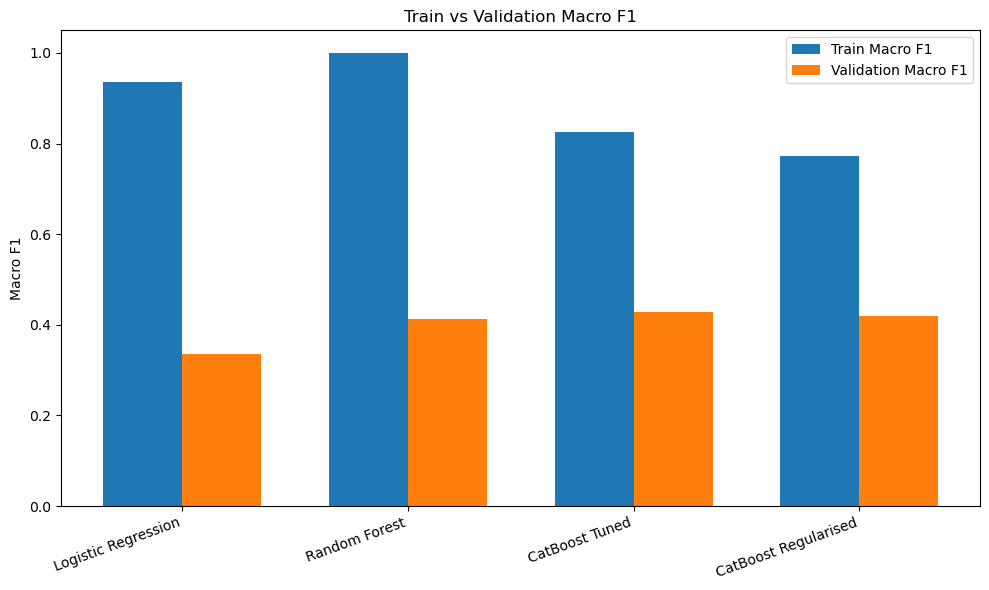

In [14]:
# -------------------------------------------------------------------
# Train vs Validation Macro F1
# -------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

models = model_results["Model"]

train_scores = model_results["Train_Macro_F1"]
validation_scores = model_results["Validation_Macro_F1"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    train_scores,
    width,
    label="Train Macro F1",
)

plt.bar(
    x + width / 2,
    validation_scores,
    width,
    label="Validation Macro F1",
)

plt.xticks(
    x,
    models,
    rotation=20,
    ha="right",
)

plt.ylabel("Macro F1")
plt.title("Train vs Validation Macro F1")
plt.ylim(0, 1.05)

plt.legend()
plt.tight_layout()
plt.show()

## Regularised Random Forest Search

The default Random Forest achieved a validation accuracy of 0.4776, the same as the other tree-based models, and a validation Macro F1 of 0.4132, but it completely fitted the training data.

A second experiment therefore constrains tree complexity and increases regularisation to determine whether similar validation performance can be preserved with improved generalisation.

In [15]:
# -------------------------------------------------------------------
# Regularised Random Forest Search
# -------------------------------------------------------------------

from sklearn.model_selection import RandomizedSearchCV

regularised_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                class_weight="balanced_subsample",
                n_jobs=-1,
            ),
        ),
    ]
)

rf_param_grid = {
    "classifier__n_estimators": [
        300,
        500,
        800,
        1200,
    ],
    "classifier__max_depth": [
        3,
        5,
        7,
        10,
        None,
    ],
    "classifier__min_samples_split": [
        2,
        5,
        10,
        15,
    ],
    "classifier__min_samples_leaf": [
        1,
        2,
        4,
        6,
        10,
    ],
    "classifier__max_features": [
        "sqrt",
        "log2",
        0.5,
    ],
}

rf_search = RandomizedSearchCV(
    estimator=regularised_rf,
    param_distributions=rf_param_grid,
    n_iter=40,
    scoring="f1_macro",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    error_score="raise",
)

rf_search.fit(
    X_train_model,
    y_train,
    groups=train_groups,
)

print("REGULARISED RANDOM FOREST SEARCH COMPLETE")
print("-" * 70)

print(
    f"Best CV Macro F1: "
    f"{rf_search.best_score_:.4f}"
)

print()
print("Best Parameters:")
print(rf_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
REGULARISED RANDOM FOREST SEARCH COMPLETE
----------------------------------------------------------------------
Best CV Macro F1: 0.4149

Best Parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 0.5, 'classifier__max_depth': 7}


### Regularised Random Forest Generalisation Check

The best regularised Random Forest configuration is evaluated on both training and validation data.

This determines whether the stronger cross-validation result is accompanied by improved generalisation or whether the model still substantially overfits the training properties.

In [16]:
# -------------------------------------------------------------------
# Regularised Random Forest Generalisation Check
# -------------------------------------------------------------------

best_regularised_rf = rf_search.best_estimator_

# Predictions.
reg_rf_train_predictions = best_regularised_rf.predict(
    X_train_model
)

reg_rf_val_predictions = best_regularised_rf.predict(
    X_val_model
)

reg_rf_val_probabilities = best_regularised_rf.predict_proba(
    X_val_model
)

reg_rf_classes = best_regularised_rf.named_steps[
    "classifier"
].classes_

# ---------------------------------------------------------------
# Training metrics
# ---------------------------------------------------------------

reg_rf_train_accuracy = accuracy_score(
    y_train,
    reg_rf_train_predictions,
)

reg_rf_train_macro_f1 = f1_score(
    y_train,
    reg_rf_train_predictions,
    average="macro",
    zero_division=0,
)

# ---------------------------------------------------------------
# Validation metrics
# ---------------------------------------------------------------

reg_rf_val_accuracy = accuracy_score(
    y_val,
    reg_rf_val_predictions,
)

reg_rf_val_macro_f1 = f1_score(
    y_val,
    reg_rf_val_predictions,
    average="macro",
    zero_division=0,
)

reg_rf_val_weighted_f1 = f1_score(
    y_val,
    reg_rf_val_predictions,
    average="weighted",
    zero_division=0,
)

reg_rf_val_top2 = top_k_accuracy_score(
    y_val,
    reg_rf_val_probabilities,
    k=2,
    labels=reg_rf_classes,
)

reg_rf_val_top3 = top_k_accuracy_score(
    y_val,
    reg_rf_val_probabilities,
    k=3,
    labels=reg_rf_classes,
)

# ---------------------------------------------------------------
# Generalisation gaps
# ---------------------------------------------------------------

reg_rf_accuracy_gap = (
    reg_rf_train_accuracy
    - reg_rf_val_accuracy
)

reg_rf_macro_f1_gap = (
    reg_rf_train_macro_f1
    - reg_rf_val_macro_f1
)

# ---------------------------------------------------------------
# Add experiment to tracking table
# ---------------------------------------------------------------

new_result = pd.DataFrame(
    [
        {
            "Model": "Random Forest Regularised",
            "Train_Accuracy": reg_rf_train_accuracy,
            "Validation_Accuracy": reg_rf_val_accuracy,
            "Train_Macro_F1": reg_rf_train_macro_f1,
            "Validation_Macro_F1": reg_rf_val_macro_f1,
            "Validation_Weighted_F1": reg_rf_val_weighted_f1,
            "Validation_Top2": reg_rf_val_top2,
            "Validation_Top3": reg_rf_val_top3,
            "Accuracy_Gap": reg_rf_accuracy_gap,
            "Macro_F1_Gap": reg_rf_macro_f1_gap,
        }
    ]
)

model_results = pd.concat(
    [
        model_results,
        new_result,
    ],
    ignore_index=True,
)

print("REGULARISED RANDOM FOREST GENERALISATION CHECK")
print("-" * 70)

print("TRAIN")
print(f"Accuracy:       {reg_rf_train_accuracy:.4f}")
print(f"Macro F1:       {reg_rf_train_macro_f1:.4f}")

print()

print("VALIDATION")
print(f"Accuracy:       {reg_rf_val_accuracy:.4f}")
print(f"Macro F1:       {reg_rf_val_macro_f1:.4f}")
print(f"Weighted F1:    {reg_rf_val_weighted_f1:.4f}")
print(f"Top-2 Accuracy: {reg_rf_val_top2:.4f}")
print(f"Top-3 Accuracy: {reg_rf_val_top3:.4f}")

print()

print("GENERALISATION GAP")
print(f"Accuracy gap:   {reg_rf_accuracy_gap:.4f}")
print(f"Macro F1 gap:   {reg_rf_macro_f1_gap:.4f}")

REGULARISED RANDOM FOREST GENERALISATION CHECK
----------------------------------------------------------------------
TRAIN
Accuracy:       0.7864
Macro F1:       0.8129

VALIDATION
Accuracy:       0.4776
Macro F1:       0.4245
Weighted F1:    0.4327
Top-2 Accuracy: 0.6716
Top-3 Accuracy: 0.8060

GENERALISATION GAP
Accuracy gap:   0.3088
Macro F1 gap:   0.3884


### Model Comparison

All modelling experiments are compared using validation performance and the train-validation generalisation gap.

This comparison highlights the trade-off between predictive performance and overfitting across increasingly regularised models.

In [17]:
# -------------------------------------------------------------------
# Model Comparison
# -------------------------------------------------------------------

comparison_columns = [
    "Model",
    "Train_Macro_F1",
    "Validation_Macro_F1",
    "Macro_F1_Gap",
    "Validation_Accuracy",
    "Validation_Top2",
    "Validation_Top3",
]

model_comparison = (
    model_results[comparison_columns]
    .sort_values(
        by="Validation_Macro_F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("MODEL COMPARISON")
print("-" * 110)

print(
    model_comparison
    .round(4)
    .to_string(index=False)
)

MODEL COMPARISON
--------------------------------------------------------------------------------------------------------------
                    Model  Train_Macro_F1  Validation_Macro_F1  Macro_F1_Gap  Validation_Accuracy  Validation_Top2  Validation_Top3
           CatBoost Tuned          0.8251               0.4288        0.3963               0.4776           0.7313           0.8358
Random Forest Regularised          0.8129               0.4245        0.3884               0.4776           0.6716           0.8060
     CatBoost Regularised          0.7736               0.4190        0.3546               0.4776           0.7313           0.8358
            Random Forest          1.0000               0.4132        0.5868               0.4776           0.6119           0.7612
      Logistic Regression          0.9350               0.3360        0.5990               0.3582           0.5672           0.7910


## AI Feature Ablation Experiment

An ablation experiment is performed to measure the contribution of myVal's existing AI-analysis outputs to the next-category recommendation model.

The same regularised Random Forest configuration is trained without AI-derived features. Keeping the modelling approach unchanged allows the difference in validation performance to be interpreted as evidence of the predictive value provided by the upstream AI system.

In [18]:
# -------------------------------------------------------------------
# AI Feature Ablation Experiment
# -------------------------------------------------------------------

from sklearn.base import clone

# Identify all features derived from the existing AI-analysis system.
ai_features = [
    column
    for column in X_train_model.columns
    if column.startswith("ai_")
]

print("AI ABLATION EXPERIMENT")
print("-" * 70)

print(f"AI features removed: {len(ai_features)}")
print(ai_features)

# ---------------------------------------------------------------
# Remove AI-derived features
# ---------------------------------------------------------------

X_train_no_ai = X_train_model.drop(
    columns=ai_features,
).copy()

X_val_no_ai = X_val_model.drop(
    columns=ai_features,
).copy()

# ---------------------------------------------------------------
# Rebuild preprocessing for the reduced feature set
# ---------------------------------------------------------------

categorical_no_ai = (
    X_train_no_ai
    .select_dtypes(
        include=["object", "string", "bool"]
    )
    .columns
    .tolist()
)

numerical_no_ai = (
    X_train_no_ai
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

preprocessor_no_ai = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_no_ai,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_no_ai,
        ),
    ]
)

# ---------------------------------------------------------------
# Use the SAME best regularised Random Forest parameters
# ---------------------------------------------------------------

rf_no_ai = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_no_ai,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=800,
                min_samples_split=15,
                min_samples_leaf=1,
                max_features="sqrt",
                max_depth=None,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_no_ai.fit(
    X_train_no_ai,
    y_train,
)

# ---------------------------------------------------------------
# Evaluate on validation only
# ---------------------------------------------------------------

no_ai_predictions = rf_no_ai.predict(
    X_val_no_ai
)

no_ai_probabilities = rf_no_ai.predict_proba(
    X_val_no_ai
)

no_ai_classes = rf_no_ai.named_steps[
    "classifier"
].classes_

no_ai_accuracy = accuracy_score(
    y_val,
    no_ai_predictions,
)

no_ai_macro_f1 = f1_score(
    y_val,
    no_ai_predictions,
    average="macro",
    zero_division=0,
)

no_ai_weighted_f1 = f1_score(
    y_val,
    no_ai_predictions,
    average="weighted",
    zero_division=0,
)

no_ai_top2 = top_k_accuracy_score(
    y_val,
    no_ai_probabilities,
    k=2,
    labels=no_ai_classes,
)

no_ai_top3 = top_k_accuracy_score(
    y_val,
    no_ai_probabilities,
    k=3,
    labels=no_ai_classes,
)

print()
print("WITHOUT AI FEATURES")
print("-" * 70)

print(f"Validation Accuracy:    {no_ai_accuracy:.4f}")
print(f"Validation Macro F1:    {no_ai_macro_f1:.4f}")
print(f"Validation Weighted F1: {no_ai_weighted_f1:.4f}")
print(f"Validation Top-2 Acc:   {no_ai_top2:.4f}")
print(f"Validation Top-3 Acc:   {no_ai_top3:.4f}")

AI ABLATION EXPERIMENT
----------------------------------------------------------------------
AI features removed: 13
['ai_asset_count', 'ai_category_match_rate', 'ai_suggestion_acceptance_rate', 'ai_estimated_value_total', 'ai_estimated_value_mean', 'ai_estimated_value_max', 'ai_count_CAT-001', 'ai_count_CAT-002', 'ai_count_CAT-003', 'ai_count_CAT-004', 'ai_count_CAT-005', 'ai_count_CAT-006', 'ai_count_CAT-007']

WITHOUT AI FEATURES
----------------------------------------------------------------------
Validation Accuracy:    0.3582
Validation Macro F1:    0.2954
Validation Weighted F1: 0.2940
Validation Top-2 Acc:   0.6567
Validation Top-3 Acc:   0.7910


In [19]:
# -------------------------------------------------------------------
# Add AI Ablation Result To Model Tracking
# -------------------------------------------------------------------

no_ai_train_predictions = rf_no_ai.predict(
    X_train_no_ai
)

no_ai_train_accuracy = accuracy_score(
    y_train,
    no_ai_train_predictions,
)

no_ai_train_macro_f1 = f1_score(
    y_train,
    no_ai_train_predictions,
    average="macro",
    zero_division=0,
)

ablation_result = pd.DataFrame(
    [
        {
            "Model": "Random Forest Regularised - No AI",
            "Train_Accuracy": no_ai_train_accuracy,
            "Validation_Accuracy": no_ai_accuracy,
            "Train_Macro_F1": no_ai_train_macro_f1,
            "Validation_Macro_F1": no_ai_macro_f1,
            "Validation_Weighted_F1": no_ai_weighted_f1,
            "Validation_Top2": no_ai_top2,
            "Validation_Top3": no_ai_top3,
            "Accuracy_Gap": (
                no_ai_train_accuracy
                - no_ai_accuracy
            ),
            "Macro_F1_Gap": (
                no_ai_train_macro_f1
                - no_ai_macro_f1
            ),
        }
    ]
)

model_results = pd.concat(
    [
        model_results,
        ablation_result,
    ],
    ignore_index=True,
)

print("UPDATED MODEL RESULTS")
print("-" * 120)

print(
    model_results
    .round(4)
    .to_string(index=False)
)

UPDATED MODEL RESULTS
------------------------------------------------------------------------------------------------------------------------
                            Model  Train_Accuracy  Validation_Accuracy  Train_Macro_F1  Validation_Macro_F1  Validation_Weighted_F1  Validation_Top2  Validation_Top3  Accuracy_Gap  Macro_F1_Gap
              Logistic Regression          0.9159               0.3582          0.9350               0.3360                  0.3480           0.5672           0.7910        0.5576        0.5990
                    Random Forest          1.0000               0.4776          1.0000               0.4132                  0.4208           0.6119           0.7612        0.5224        0.5868
                   CatBoost Tuned          0.7994               0.4776          0.8251               0.4288                  0.4316           0.7313           0.8358        0.3217        0.3963
             CatBoost Regularised          0.7508               0.4776          0

## Feature Importance

Feature importance is examined for the regularised Random Forest model to identify which household, AI-derived, property and customer signals contribute most strongly to the next-category recommendation.

The analysis is descriptive rather than causal: importance indicates that a feature is useful to the fitted model, but does not imply that the feature causes a customer to document a particular category next.

In [20]:
# -------------------------------------------------------------------
# Random Forest Feature Importance
# -------------------------------------------------------------------

# Retrieve the fitted preprocessing and classifier components.
fitted_preprocessor = best_regularised_rf.named_steps[
    "preprocessor"
]

fitted_rf = best_regularised_rf.named_steps[
    "classifier"
]

# Recover the transformed feature names after preprocessing.
feature_names = fitted_preprocessor.get_feature_names_out()

# Build a ranked feature-importance table.
feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": fitted_rf.feature_importances_,
    }
).sort_values(
    by="Importance",
    ascending=False,
).reset_index(drop=True)

print("TOP 25 RANDOM FOREST FEATURES")
print("-" * 100)

print(
    feature_importance
    .head(25)
    .round(4)
    .to_string(index=False)
)

TOP 25 RANDOM FOREST FEATURES
----------------------------------------------------------------------------------------------------
                                     Feature  Importance
         numerical__documented_count_CAT-001      0.1460
         numerical__documented_count_CAT-003      0.0576
                 numerical__ai_count_CAT-001      0.0418
         numerical__documented_count_CAT-005      0.0418
        numerical__documented_category_count      0.0359
    numerical__ai_suggestion_acceptance_rate      0.0326
numerical__documented_replacement_cost_total      0.0306
          numerical__ai_estimated_value_mean      0.0300
           numerical__ai_estimated_value_max      0.0300
         numerical__documented_count_CAT-006      0.0299
           numerical__Property_Valuation_AUD      0.0290
           numerical__ai_category_match_rate      0.0242
           numerical__documented_value_total      0.0237
                    numerical__Tenure_Months      0.0234
              

### Validation Permutation Importance

Permutation importance is calculated on the validation partition to estimate how much predictive performance decreases when each feature is randomly disrupted.

Unlike tree-based impurity importance, this analysis evaluates feature usefulness directly on unseen properties and therefore provides a stronger indication of which variables contribute to generalisation.

In [21]:
# -------------------------------------------------------------------
# Validation Permutation Importance
# -------------------------------------------------------------------

from sklearn.inspection import permutation_importance

# Calculate importance directly on the validation partition.
permutation_result = permutation_importance(
    best_regularised_rf,
    X_val_model,
    y_val,
    scoring="f1_macro",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

permutation_features = pd.DataFrame(
    {
        "Feature": X_val_model.columns,
        "Importance_Mean": permutation_result.importances_mean,
        "Importance_Std": permutation_result.importances_std,
    }
).sort_values(
    by="Importance_Mean",
    ascending=False,
).reset_index(drop=True)

print("TOP 25 VALIDATION PERMUTATION IMPORTANCE")
print("-" * 100)

print(
    permutation_features
    .head(25)
    .round(4)
    .to_string(index=False)
)

TOP 25 VALIDATION PERMUTATION IMPORTANCE
----------------------------------------------------------------------------------------------------
                      Feature  Importance_Mean  Importance_Std
     documented_count_CAT-001           0.1774          0.0356
     documented_count_CAT-005           0.1340          0.0310
     documented_count_CAT-006           0.1295          0.0370
     documented_count_CAT-003           0.1281          0.0513
     documented_count_CAT-002           0.0968          0.0411
ai_suggestion_acceptance_rate           0.0784          0.0361
             ai_count_CAT-005           0.0748          0.0348
       Property_Valuation_AUD           0.0742          0.0349
              Engagement_Tier           0.0664          0.0280
       Prior_Claim_Experience           0.0605          0.0392
    documented_category_count           0.0588          0.0200
       documented_asset_count           0.0584          0.0292
             ai_count_CAT-003          

## Final Holdout Evaluation By Recommendation Objective

The final models are selected using validation performance only.

The standard Random Forest is retained for the primary Top-1 recommendation, while the regularised Random Forest is retained for Top-2 and Top-3 ranked recommendations.

The untouched test partition is evaluated once to estimate final performance on unseen properties.

In [22]:
# -------------------------------------------------------------------
# Final Holdout Evaluation By Recommendation Objective
# -------------------------------------------------------------------

# Prepare untouched test predictors.
X_test_model = X_test.drop(
    columns=[
        "Property_ID",
        "Customer_ID",
        "Prediction_Time",
    ],
    errors="ignore",
).copy()

# ---------------------------------------------------------------
# Top-1 Model: Standard Random Forest
# ---------------------------------------------------------------

top1_predictions = random_forest_model.predict(
    X_test_model
)

top1_accuracy = accuracy_score(
    y_test,
    top1_predictions,
)

top1_macro_f1 = f1_score(
    y_test,
    top1_predictions,
    average="macro",
    zero_division=0,
)

top1_weighted_f1 = f1_score(
    y_test,
    top1_predictions,
    average="weighted",
    zero_division=0,
)

# ---------------------------------------------------------------
# Top-2 / Top-3 Model: Regularised Random Forest
# ---------------------------------------------------------------

ranking_probabilities = best_regularised_rf.predict_proba(
    X_test_model
)

ranking_classes = best_regularised_rf.named_steps[
    "classifier"
].classes_

top2_accuracy = top_k_accuracy_score(
    y_test,
    ranking_probabilities,
    k=2,
    labels=ranking_classes,
)

top3_accuracy = top_k_accuracy_score(
    y_test,
    ranking_probabilities,
    k=3,
    labels=ranking_classes,
)

# ---------------------------------------------------------------
# Final results
# ---------------------------------------------------------------

print("FINAL HOLDOUT TEST RESULTS")
print("-" * 70)

print("TOP-1 MODEL — RANDOM FOREST")
print(f"Accuracy:    {top1_accuracy:.4f}")
print(f"Macro F1:    {top1_macro_f1:.4f}")
print(f"Weighted F1: {top1_weighted_f1:.4f}")

print()

print("RANKING MODEL — REGULARISED RANDOM FOREST")
print(f"Top-2 Accuracy: {top2_accuracy:.4f}")
print(f"Top-3 Accuracy: {top3_accuracy:.4f}")

FINAL HOLDOUT TEST RESULTS
----------------------------------------------------------------------
TOP-1 MODEL — RANDOM FOREST
Accuracy:    0.5091
Macro F1:    0.3257
Weighted F1: 0.4516

RANKING MODEL — REGULARISED RANDOM FOREST
Top-2 Accuracy: 0.7818
Top-3 Accuracy: 0.8545


## Final Per-Class Evaluation

The final Top-1 model is analysed by category to identify where recommendation performance is strongest and where minority categories remain difficult to predict.

These results are used for interpretation only. No further model tuning is performed using the holdout test set.

In [23]:
# -------------------------------------------------------------------
# Final Per-Class Evaluation
# -------------------------------------------------------------------

from sklearn.metrics import classification_report, confusion_matrix

# Classification metrics by target category.
print("FINAL TOP-1 CLASSIFICATION REPORT")
print("-" * 80)

print(
    classification_report(
        y_test,
        top1_predictions,
        digits=4,
        zero_division=0,
    )
)

# Confusion matrix.
confusion = pd.DataFrame(
    confusion_matrix(
        y_test,
        top1_predictions,
        labels=random_forest_model.classes_,
    ),
    index=random_forest_model.classes_,
    columns=random_forest_model.classes_,
)

print()
print("FINAL TOP-1 CONFUSION MATRIX")
print("-" * 80)

print(
    confusion.to_string()
)

FINAL TOP-1 CLASSIFICATION REPORT
--------------------------------------------------------------------------------
                              precision    recall  f1-score   support

                  Appliances     0.3750    0.2727    0.3158        11
                   Clothings     0.0000    0.0000    0.0000         3
                 Electronics     0.6667    1.0000    0.8000        12
                   Furniture     0.5882    0.8333    0.6897        12
Jewellery and Personal Items     0.2500    0.1250    0.1667         8
                 Other Items     0.3333    0.2857    0.3077         7
                    Vehicles     0.0000    0.0000    0.0000         2

                    accuracy                         0.5091        55
                   macro avg     0.3162    0.3595    0.3257        55
                weighted avg     0.4276    0.5091    0.4516        55


FINAL TOP-1 CONFUSION MATRIX
--------------------------------------------------------------------------------
 

## Modelling Conclusion

The final evaluation shows that the recommendation problem is substantially easier when treated as a ranked recommendation task rather than as a strict single-class prediction problem.

The Top-1 Random Forest achieved 50.91% accuracy on the untouched holdout set, but performance varied substantially across categories. Electronics and Furniture were predicted most reliably, while minority categories remained difficult to identify: Clothings and Vehicles were never predicted correctly, and Jewellery and Personal Items reached a recall of only 0.1250.

The ranking formulation produced stronger results. The regularised Random Forest achieved 78.18% Top-2 accuracy and 85.45% Top-3 accuracy, indicating that the correct next category was frequently present among the highest-ranked recommendations even when the first prediction was incorrect.

The experiments also showed that AI-derived features contributed useful predictive information. Removing these features reduced validation Macro F1 from 0.4245 to 0.2954, supporting the use of myVal's existing AI outputs as upstream signals for the recommendation model.

Five features derived from the household-value regression were also added to the modelling dataset: the documented value without vehicles, and the regression estimate of the household's total value, the estimated undocumented gap and the completeness, which are available only for the 71 of 431 states with at least ten documented non-vehicle items. They did not show a consistent benefit. Their validation permutation importance was low (about 0.03 for the estimated total and the gap, well below the documented category counts), and a separate comparison of the same Random Forest trained with and without the five columns over 20 random seeds produced differences smaller than the variation between seeds (validation Top-1 accuracy 0.4478 with and 0.4455 without the columns). Only 10 validation and 8 holdout states carry a regression estimate, so any effect would be difficult to detect, and the changes in holdout accuracy relative to the earlier results should not be attributed to these features.

Model selection is a further limitation of the current results. The four tree-based models reached the same validation accuracy (0.4776), and the two CatBoost models obtained the highest validation Top-2 and Top-3 accuracy (0.7313 and 0.8358), while the standard and the regularised Random Forest were retained for the final evaluation as originally designed. With 67 validation and 55 holdout states, a difference of a single state corresponds to about 1.5 to 1.8 percentage points, so small differences between models should be interpreted with caution.

Overfitting remained an important limitation across all models because of the relatively small number of historical prediction states. Regularisation reduced the train-validation gap, but the results suggest that additional household histories and better representation of minority categories would likely improve future generalisation.

## Save Final Models

The selected Top-1 and ranking models are persisted for reuse in inference and deployment workflows.

In [24]:
# -------------------------------------------------------------------
# Save Final Models
# -------------------------------------------------------------------

from pathlib import Path
import joblib

MODELS_DIR = Path("../../models/classification")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

top1_model_path = MODELS_DIR / "next_category_top1_random_forest.joblib"
ranking_model_path = MODELS_DIR / "next_category_ranking_random_forest.joblib"

joblib.dump(
    random_forest_model,
    top1_model_path,
)

joblib.dump(
    best_regularised_rf,
    ranking_model_path,
)

print("FINAL MODELS SAVED")
print("-" * 60)
print(f"Top-1 model:   {top1_model_path}")
print(f"Ranking model: {ranking_model_path}")

FINAL MODELS SAVED
------------------------------------------------------------
Top-1 model:   ..\models\next_category_top1_random_forest.joblib
Ranking model: ..\models\next_category_ranking_random_forest.joblib
